# Load and Inspect Combined Forecast Dataset (ICON-D2 + GEFS)

This notebook demonstrates how to load and inspect the CombinedForecastDataset which merges:
- **ICON-D2**: Short-range 48h forecasts (high resolution, local NetCDF)
- **GEFS**: Extended 10-day forecasts (NOAA Zarr store)

Key features:
- ICON-D2 variables are suffixed with `_icond2`
- ICON-D2 data is zero-padded for lead times beyond 48h
- `icond2_available` mask indicates where ICON-D2 data is valid (1 for h1-48, 0 for h49-240)

In [1]:
import sys
import torch
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from datetime import timedelta
from pathlib import Path
from matplotlib import dates as mdates

from neuralhydrology.utils.config import Config
from neuralhydrology.datasetzoo.onlineforecast_combined_dataset import CombinedForecastDataset

## Load Configuration

Load the configuration file that specifies both ICON-D2 and GEFS variables.

In [2]:
# Load the config file
config = Config(Path("config_icond2_gefs.yml"))

## Create Combined Forecast Dataset

Initialize the CombinedForecastDataset which will:
1. Load ICON-D2 data from local NetCDF files
2. Load GEFS data from NOAA Zarr store
3. Merge them with zero-padding for ICON-D2 beyond 48h

In [3]:
# Initialize the dataset
# Explicitly pass scaler={} to ensure a fresh empty dict is used 
# (avoids Python mutable default argument issue)
dataset = CombinedForecastDataset(cfg=config, is_train=True, period='train', scaler={})

100%|██████████| 5/5 [06:30<00:00, 78.12s/it]


## Inspect the Merged XArray Dataset

Examine the structure of the combined dataset showing both ICON-D2 and GEFS variables.

In [4]:
# Access the internal xarray dataset
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
else:
    xr_dataset = dataset._load_or_create_xarray_dataset()

    print("=== XArray Dataset Structure ===")
    print(xr_dataset)

    print("\n=== Variables by Source ===")
    icond2_vars = [v for v in xr_dataset.data_vars if '_icond2' in v]
    gefs_vars = [v for v in xr_dataset.data_vars if '_icond2' not in v and v != 'icond2_available']
    print(f"ICON-D2 variables: {icond2_vars}")
    print(f"GEFS variables: {gefs_vars}")
    print(f"Mask: {'icond2_available' in xr_dataset.data_vars}")

=== XArray Dataset Structure ===
<xarray.Dataset> Size: 242MB
Dimensions:                          (basin: 5, gauge_id: 1, issue_time: 1175,
                                      lead_time: 240, time: 29400)
Coordinates:
    latitude                         (basin) float64 40B 51.75 51.75 ... 52.0
  * lead_time                        (lead_time) int64 2kB 1 2 3 ... 238 239 240
    expected_forecast_length         (issue_time) timedelta64[ns] 9kB 35 days...
  * basin                            (basin) object 40B 'DE1' 'DE2' ... 'DE5'
  * issue_time                       (issue_time) datetime64[ns] 9kB 2021-02-...
    spatial_ref                      int64 8B 0
    longitude                        (basin) float64 40B 10.25 10.5 ... 10.25
  * time                             (time) datetime64[ns] 235kB 2020-12-23 ....
Dimensions without coordinates: gauge_id
Data variables: (12/35)
    precipitation_mean_icond2_q50    (basin, gauge_id, issue_time, lead_time) float64 11MB dask.array<chunks

## Plot Forecast Comparison: ICON-D2 vs GEFS

Visualize the 24.12.2023 00Z forecast showing:
- Historical observations (past 7 days)
- ICON-D2 forecast (0-48h, high resolution)
- GEFS forecast (0-240h, extended range)
- The `icond2_available` mask

In [7]:
# Select basin and target issue time
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
else:
    basin_id = 'DE2'  # Ecker catchment
    target_issue_time = pd.Timestamp('2023-12-24 00:00:00')

    # Select data for this basin
    ds = xr_dataset.sel(basin=basin_id)

    # Check if target issue time exists
    available_issues = pd.to_datetime(ds['issue_time'].values)
    if target_issue_time not in available_issues:
        print(f"Warning: {target_issue_time} not found. Using nearest available.")
        idx = available_issues.get_indexer([target_issue_time], method='nearest')[0]
        target_issue_time = available_issues[idx]
        print(f"Using: {target_issue_time}")

In [8]:
# Extract forecast data
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
else:
    fcst = ds.sel(issue_time=target_issue_time)
    lead_times = fcst['lead_time'].values  # Hours (integer)
    forecast_dates = target_issue_time + pd.to_timedelta(lead_times, unit='h')

    # Extract historical data (7 days before forecast)
    hist_end = target_issue_time
    hist_start = hist_end - pd.Timedelta(days=7)
    
    # Check if 'time' dimension exists and has data in this range
    if 'time' in ds.dims:
        hist = ds.sel(time=slice(hist_start, hist_end))
        hist_dates = pd.to_datetime(hist['time'].values)
        print(f"Historical period: {hist_start} to {hist_end} ({len(hist_dates)} timesteps)")
    else:
        hist = None
        hist_dates = []
        print("No historical time dimension found.")
    
    print(f"Forecast period: {forecast_dates[0]} to {forecast_dates[-1]}")
    print(f"Lead times: {lead_times[0]}h to {lead_times[-1]}h ({len(lead_times)} steps)")

Historical period: 2023-12-17 00:00:00 to 2023-12-24 00:00:00 (169 timesteps)
Forecast period: 2023-12-24 01:00:00 to 2024-01-03 00:00:00
Lead times: 1h to 240h (240 steps)


Saved: forecast_comparison.png/pdf (6x5 inches, 300 dpi, transparent)


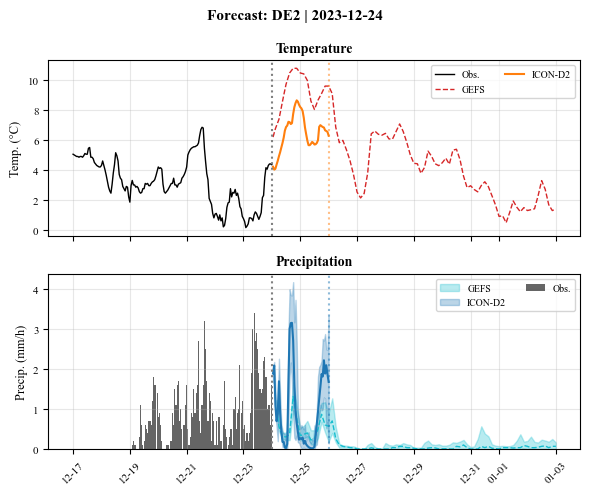

In [9]:
# Create comparison plot - Optimized for PowerPoint (side-by-side with distribution plot)
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
else:
    import matplotlib as mpl
    plt.rcParams["font.family"] = "Times New Roman"
    
    # PowerPoint optimized: 6x5 inches for side-by-side placement
    fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)
    fig.patch.set_alpha(0)  # Transparent figure background
    for ax in axes:
        ax.patch.set_alpha(0)  # Transparent axes background

    def flatten(arr):
        return np.array(arr).flatten()

    TEMP_VAR_GEFS = "temperature_2m_gefs_q50"
    PRECIP_VAR_GEFS = "precipitation_surface_gefs_q50"
    PRECIP_VAR_GEFS_Q25 = "precipitation_surface_gefs_q25"
    PRECIP_VAR_GEFS_Q75 = "precipitation_surface_gefs_q75"

    # Colors: Red/Orange for temp, Blue/Cyan for precip
    temp_color_gefs = "C3"
    temp_color_icond2 = "C1"
    precip_color_gefs = "C9"
    precip_color_icond2 = "C0"

    # --- Temperature ---
    ax = axes[0]
    if hist is not None and "temperature_2m" in hist.data_vars and len(hist_dates) > 0:
        ax.plot(hist_dates, flatten(hist["temperature_2m"].values), "k-", lw=1, label="Obs.")
    if TEMP_VAR_GEFS in fcst.data_vars:
        gefs_temp = flatten(fcst[TEMP_VAR_GEFS].values)
        if np.nanmean(gefs_temp) > 200: gefs_temp = gefs_temp - 273.15
        ax.plot(forecast_dates, gefs_temp, color=temp_color_gefs, ls="--", lw=1, label="GEFS")
    if "temperature_mean_icond2" in fcst.data_vars:
        icond2_temp = flatten(fcst["temperature_mean_icond2"].values)
        mask = flatten(fcst["icond2_available"].values) == 1 if "icond2_available" in fcst.data_vars else lead_times <= 48
        if np.nanmean(icond2_temp[mask]) > 200: icond2_temp = icond2_temp - 273.15
        ax.plot(forecast_dates[mask], icond2_temp[mask], color=temp_color_icond2, lw=1.5, label="ICON-D2")
    ax.axvline(target_issue_time, color="gray", ls=":", lw=1.5)
    ax.axvline(target_issue_time + pd.Timedelta(hours=48), color=temp_color_icond2, ls=":", alpha=0.5)
    ax.set_ylabel("Temp. (°C)", fontsize=9)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)
    ax.set_title("Temperature", fontsize=10, fontweight="bold")

    # --- Precipitation ---
    ax = axes[1]
    if hist is not None and "precipitation" in hist.data_vars and len(hist_dates) > 0:
        ax.bar(hist_dates, flatten(hist["precipitation"].values), width=0.04, color="black", alpha=0.6, label="Obs.")
    if PRECIP_VAR_GEFS in fcst.data_vars:
        gefs_q25 = flatten(fcst[PRECIP_VAR_GEFS_Q25].values) * 3600
        gefs_q50 = flatten(fcst[PRECIP_VAR_GEFS].values) * 3600
        gefs_q75 = flatten(fcst[PRECIP_VAR_GEFS_Q75].values) * 3600
        ax.fill_between(forecast_dates, gefs_q25, gefs_q75, color=precip_color_gefs, alpha=0.3, label="GEFS")
        ax.plot(forecast_dates, gefs_q50, color=precip_color_gefs, ls="--", lw=1)
    quartile_vars = ["precipitation_mean_icond2_q25", "precipitation_mean_icond2_q50", "precipitation_mean_icond2_q75"]
    if all(v in fcst.data_vars for v in quartile_vars):
        q25, q50, q75 = [flatten(fcst[v].values) for v in quartile_vars]
        mask = flatten(fcst["icond2_available"].values) == 1 if "icond2_available" in fcst.data_vars else lead_times <= 48
        ax.fill_between(forecast_dates[mask], q25[mask], q75[mask], color=precip_color_icond2, alpha=0.3, label="ICON-D2")
        ax.plot(forecast_dates[mask], q50[mask], color=precip_color_icond2, lw=1.5)
    ax.axvline(target_issue_time, color="gray", ls=":", lw=1.5)
    ax.axvline(target_issue_time + pd.Timedelta(hours=48), color=precip_color_icond2, ls=":", alpha=0.5)
    ax.set_ylabel("Precip. (mm/h)", fontsize=9)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)
    ax.set_title("Precipitation", fontsize=10, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    plt.xticks(rotation=45)

    plt.suptitle(f"Forecast: {basin_id} | {target_issue_time.strftime("%Y-%m-%d")}", fontsize=11, fontweight="bold", y=0.98)
    plt.tight_layout()
    
    # Export with transparent background
    fig.savefig("forecast_comparison.png", dpi=300, bbox_inches="tight", transparent=True)
    fig.savefig("forecast_comparison.pdf", bbox_inches="tight", transparent=True)
    print("Saved: forecast_comparison.png/pdf (6x5 inches, 300 dpi, transparent)")
    plt.show()
    plt.rcParams["font.family"] = mpl.rcParamsDefault["font.family"]

## Inspect a Single Sample

Let's look at what a single training sample looks like from the dataset.

In [10]:
# Get a sample from the dataset
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
else:
    sample_idx = 0
    sample = dataset[sample_idx]

    print("=== Sample Structure ===")
    for key, value in sample.items():
        if isinstance(value, torch.Tensor):
            print(f"{key}: shape={value.shape}, dtype={value.dtype}")
        elif isinstance(value, dict):
            print(f"{key}: dict with {len(value)} keys")
        else:
            print(f"{key}: {type(value).__name__}")

=== Sample Structure ===
x_h: shape=torch.Size([1200, 13]), dtype=torch.float32
x_f: shape=torch.Size([240, 21]), dtype=torch.float32
x_d_hindcast: dict with 13 keys
x_d_forecast: dict with 21 keys
y: shape=torch.Size([1440, 1]), dtype=torch.float32
date: ndarray
date_issue: datetime64
x_s: shape=torch.Size([18]), dtype=torch.float32


In [11]:
# Examine forecast inputs tensor
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
elif 'x_f' in sample:
    x_f = sample['x_f']
    print(f"Forecast tensor shape: {x_f.shape}")
    print(f"  - Dimension 0 (lead_time): {x_f.shape[0]} hours")
    print(f"  - Dimension 1 (features): {x_f.shape[1]} variables")
    print(f"\nForecast variables: {config.forecast_inputs}")
    
    # Check for NaN or zeros in ICON-D2 region vs padded region
    if 'icond2_available' in config.forecast_inputs:
        icond2_idx = config.forecast_inputs.index('icond2_available')
        mask = x_f[:, icond2_idx]
        valid_count = int((mask == 1).sum())
        total_count = len(mask)
        print(f"\nICON-D2 availability mask:")
        print(f"  - Valid (=1) for hours 1-{valid_count}")
        print(f"  - Padded (=0) for hours {valid_count+1}-{total_count}")
    else:
        print("\nicond2_available not in forecast_inputs")
else:
    print("No 'x_f' tensor in sample.")

Forecast tensor shape: torch.Size([240, 21])
  - Dimension 0 (lead_time): 240 hours
  - Dimension 1 (features): 21 variables

Forecast variables: ['maximum_temperature_2m_gefs_q25', 'maximum_temperature_2m_gefs_q50', 'maximum_temperature_2m_gefs_q75', 'minimum_temperature_2m_gefs_q25', 'minimum_temperature_2m_gefs_q50', 'minimum_temperature_2m_gefs_q75', 'precipitation_surface_gefs_q25', 'precipitation_surface_gefs_q50', 'precipitation_surface_gefs_q75', 'relative_humidity_2m_gefs_q25', 'relative_humidity_2m_gefs_q50', 'relative_humidity_2m_gefs_q75', 'temperature_2m_gefs_q25', 'temperature_2m_gefs_q50', 'temperature_2m_gefs_q75', 'precipitation_mean_icond2', 'precipitation_mean_icond2_q25', 'precipitation_mean_icond2_q50', 'precipitation_mean_icond2_q75', 'temperature_mean_icond2', 'icond2_available']

ICON-D2 availability mask:
  - Valid (=1) for hours 1-0
  - Padded (=0) for hours 1-240


## Precipitation Distribution Comparison

Comparing the distributions of precipitation from different data sources:
- **Station Data**: Historic observations (hindcast)
- **ICON-D2**: Short-range forecast (48h)
- **GEFS**: Extended-range forecast (10 days)

This visualization highlights that hindcast and forecast data come from different distributions.

Basin: DE2
Obs: 29,400 | ICON-D2: 53,577 | GEFS: 278,474
Saved: precipitation_distribution_comparison.png/pdf (6x5 inches, 300 dpi, transparent)


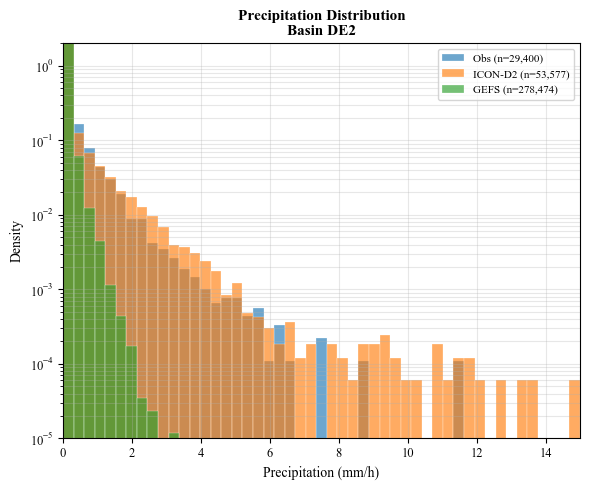

In [12]:
# Precipitation Distribution - Optimized for PowerPoint (side-by-side)
import matplotlib as mpl
plt.rcParams["font.family"] = "Times New Roman"

basin_id = "DE2"
ds = xr_dataset.sel(basin=basin_id)

# Extract precipitation data
hist_precip = ds["precipitation"].values.flatten()
hist_precip = hist_precip[~np.isnan(hist_precip) & (hist_precip >= 0)]

icond2_precip_raw = ds["precipitation_mean_icond2"].values.flatten()
icond2_mask = ds["icond2_available"].values.flatten()
icond2_precip = icond2_precip_raw[icond2_mask == 1]
icond2_precip = icond2_precip[~np.isnan(icond2_precip) & (icond2_precip >= 0)]

gefs_precip = ds["precipitation_surface_gefs_q50"].values.flatten() * 3600
gefs_precip = gefs_precip[~np.isnan(gefs_precip) & (gefs_precip >= 0)]

print(f"Basin: {basin_id}")
print(f"Obs: {len(hist_precip):,} | ICON-D2: {len(icond2_precip):,} | GEFS: {len(gefs_precip):,}")

# PowerPoint optimized: 6x5 inches with transparent background
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_alpha(0)  # Transparent figure background
ax.patch.set_alpha(0)   # Transparent axes background

bins = np.linspace(0, 15, 50)
ax.hist(hist_precip, bins=bins, alpha=0.65, label=f"Obs (n={len(hist_precip):,})", 
        color="C0", density=True, edgecolor="white", linewidth=0.3)
ax.hist(icond2_precip, bins=bins, alpha=0.65, label=f"ICON-D2 (n={len(icond2_precip):,})", 
        color="C1", density=True, edgecolor="white", linewidth=0.3)
ax.hist(gefs_precip, bins=bins, alpha=0.65, label=f"GEFS (n={len(gefs_precip):,})", 
        color="C2", density=True, edgecolor="white", linewidth=0.3)

ax.set_yscale("log")
ax.set_xlabel("Precipitation (mm/h)", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title(f"Precipitation Distribution\nBasin {basin_id}", fontsize=11, fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(0, 15)
ax.set_ylim(1e-5, 2e0)
ax.grid(True, alpha=0.3, which="both")
ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()

# Export with transparent background
fig.savefig("precipitation_distribution_comparison.png", dpi=300, bbox_inches="tight", transparent=True)
fig.savefig("precipitation_distribution_comparison.pdf", bbox_inches="tight", transparent=True)
print("Saved: precipitation_distribution_comparison.png/pdf (6x5 inches, 300 dpi, transparent)")

plt.show()
plt.rcParams["font.family"] = mpl.rcParamsDefault["font.family"]